Solving numerical reference solution...

--- Training PIKAN Model ---
PIKAN Parameters: 736
Epoch 0, Loss: 3.039053
Epoch 1000, Loss: 0.030186
Epoch 2000, Loss: 0.009245
Epoch 3000, Loss: 0.002974
Epoch 4000, Loss: 0.000987
Epoch 5000, Loss: 0.000275
Epoch 6000, Loss: 0.000114
Epoch 7000, Loss: 0.000066
Epoch 8000, Loss: 0.000041
Epoch 9000, Loss: 0.000027
Total time taken for PIKAN training: 232.46 seconds

--- Training Standard PINN Model (MLP) ---
Standard PINN Parameters: 899
Epoch 0, Loss: 3.923321
Epoch 1000, Loss: 0.003695
Epoch 2000, Loss: 0.001531
Epoch 3000, Loss: 0.000964
Epoch 4000, Loss: 0.000286
Epoch 5000, Loss: 0.000079
Epoch 6000, Loss: 0.000043
Epoch 7000, Loss: 0.000019
Epoch 8000, Loss: 0.000009
Epoch 9000, Loss: 0.000007
Total time taken for Standard PINN training: 193.34 seconds

--- Training LMKAN Model ---
LMKAN Parameters: 777
Epoch 0, Loss: 2.081996
Epoch 1000, Loss: 0.002763
Epoch 2000, Loss: 0.001870
Epoch 3000, Loss: 0.001188
Epoch 4000, Loss: 0.000054
Epoc

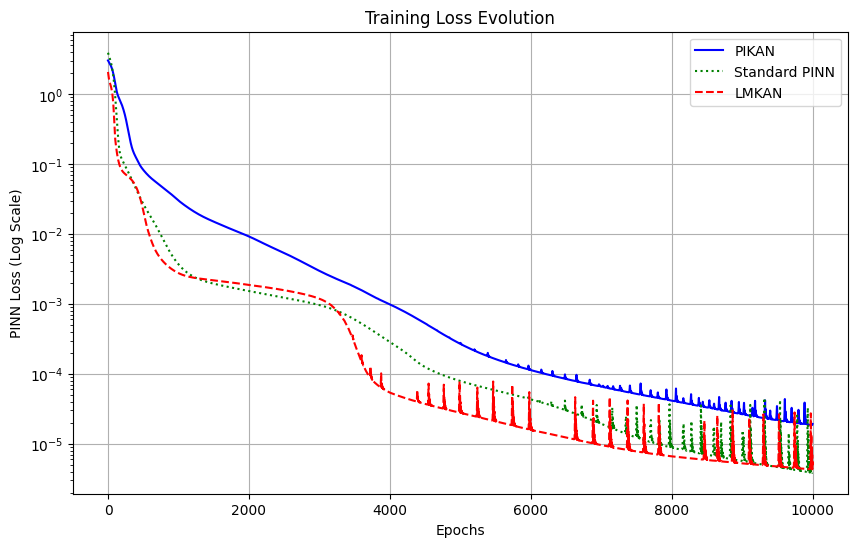

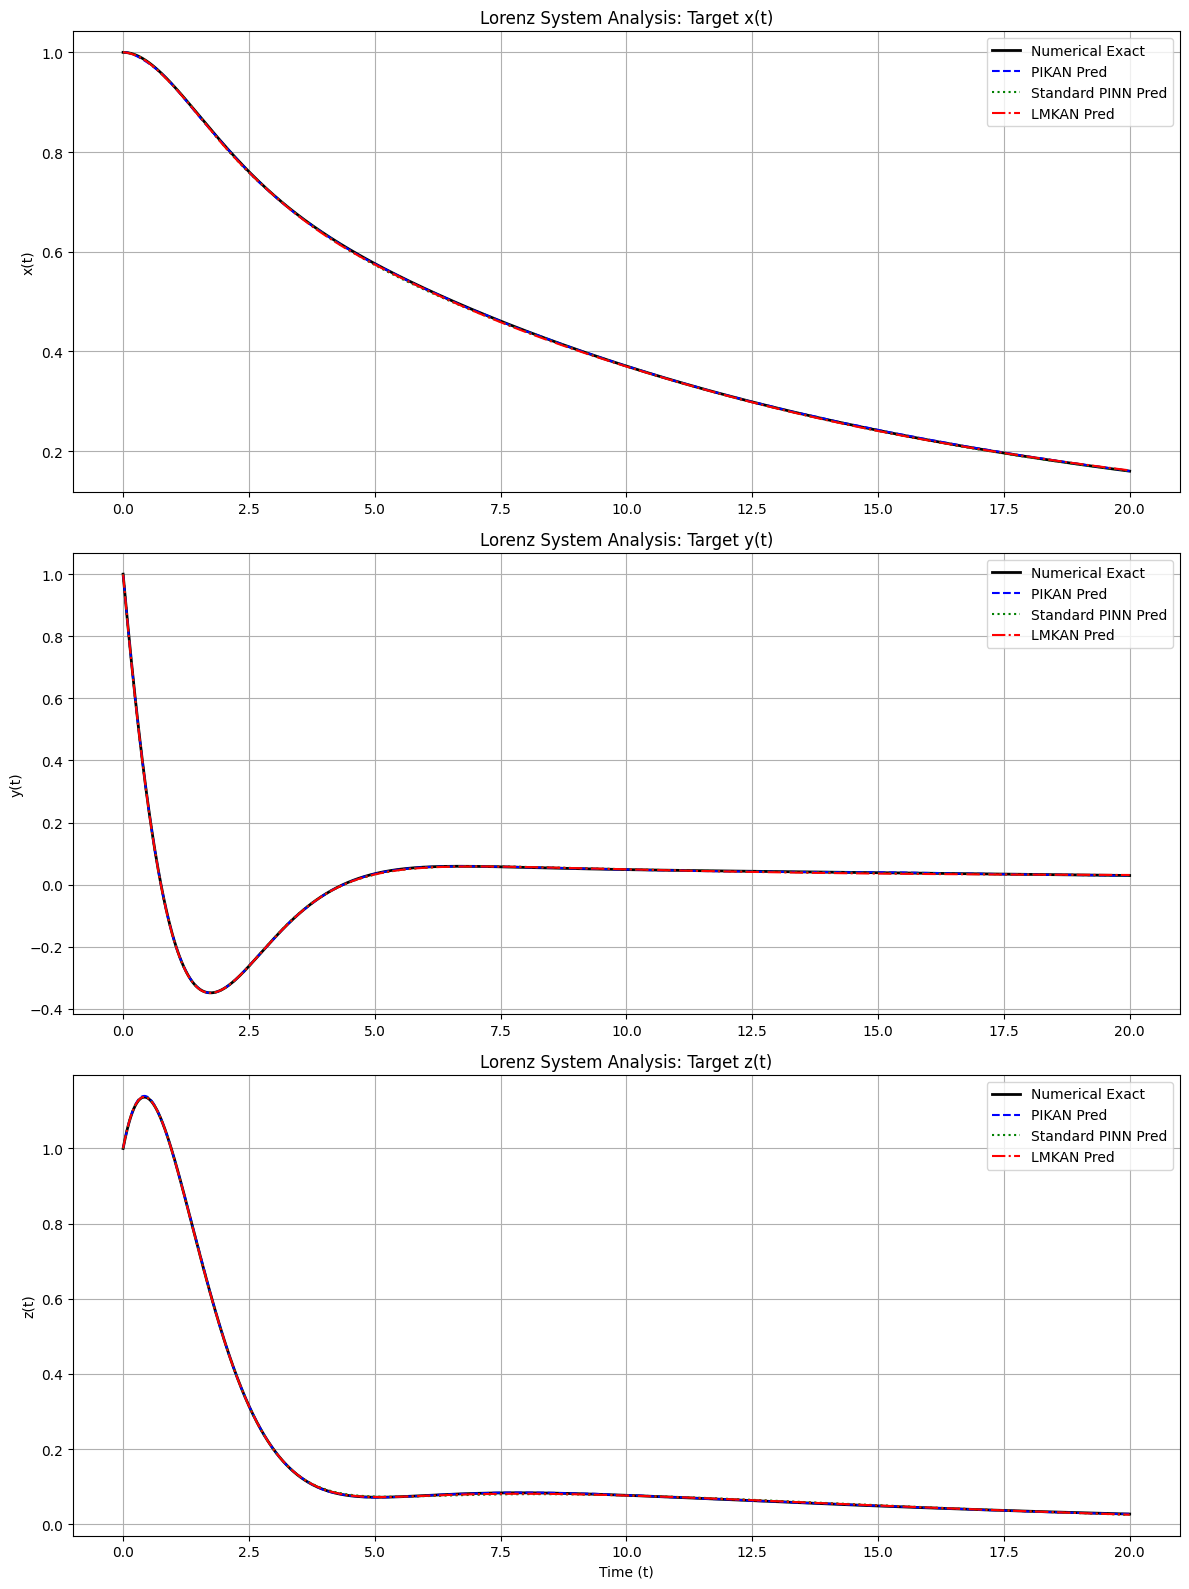

In [ ]:
import os
import time
import math

# Output directory for saving plots (change this to update the save location everywhere)
OUTPUT_DIR = "outputs"
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Import existing PIKAN (wavekan) components
import wavekan

# Import the LMKAN components
from lm_kan import LMKAN, LMKAN_WIDTH, LMKAN_DEPTH, LMKAN_K, LMKAN_BASIS, LMKAN_GAMMA, LMKAN_METRIC_HIDDEN

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class StandardPINN(nn.Module):
    def __init__(self, in_dim=1, out_dim=3, hidden_dim=64, n_layers=4):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden_dim, hidden_dim), nn.Tanh()])
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)

# ==========================================
# 1) Numerical Solution (Reference)
# ==========================================
sigma = 0.1
ro = 0.2
beta = 0.3

def lorenz(t, state):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (ro - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

initial_state = [1.0, 1.0, 1.0]
t_span = (0, 20)
t_eval = np.linspace(*t_span, 10000)

print("Solving numerical reference solution...")
sol = solve_ivp(lorenz, t_span, initial_state, t_eval=t_eval)

t_num = sol.t
x_num = sol.y[0]
y_num = sol.y[1]
z_num = sol.y[2]


# ==========================================
# 2) PINN Loss Setup
# ==========================================
# Use device appropriately if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

t_train_tensor = torch.linspace(0, 20, 100, device=device).reshape(-1, 1).type(torch.float32)
t_train_tensor.requires_grad_(True)
zero_tensor = torch.zeros_like(t_train_tensor).requires_grad_(True)
one_tensor = torch.ones_like(t_train_tensor).requires_grad_(True)

def pinn_loss(model, t):
    xyz = model(t)
    x_pred = xyz[:, 0:1]
    y_pred = xyz[:, 1:2]
    z_pred = xyz[:, 2:3]
    
    # Differential equations residuals
    dx_dt = torch.autograd.grad(x_pred, t, grad_outputs=torch.ones_like(x_pred), create_graph=True)[0]
    dy_dt = torch.autograd.grad(y_pred, t, grad_outputs=torch.ones_like(y_pred), create_graph=True)[0]
    dz_dt = torch.autograd.grad(z_pred, t, grad_outputs=torch.ones_like(z_pred), create_graph=True)[0]
    
    rhs_x = sigma * (y_pred - x_pred)
    rhs_y = x_pred * (ro - z_pred) - y_pred
    rhs_z = x_pred * y_pred - beta * z_pred
    
    L_x = torch.mean((dx_dt - rhs_x)**2)
    L_y = torch.mean((dy_dt - rhs_y)**2)
    L_z = torch.mean((dz_dt - rhs_z)**2)
    L_f = L_x + L_y + L_z
    
    # Boundary conditions
    xyz_0 = model(zero_tensor)
    x_0 = xyz_0[:, 0:1]
    y_0 = xyz_0[:, 1:2]
    z_0 = xyz_0[:, 2:3]
    L_b = torch.mean((x_0 - one_tensor)**2 + (y_0 - one_tensor)**2 + (z_0 - one_tensor)**2)
    
    loss = L_f + L_b
    return loss


# ==========================================
# 3) Train PIKAN (Baseline)
# ==========================================
print("\n--- Training PIKAN Model ---")
model_kan = wavekan.KAN([1, 8, 16, 3]).to(device)
print(f"PIKAN Parameters: {count_parameters(model_kan)}")

optimizer_kan = optim.AdamW(model_kan.parameters(), lr=0.0005)
loss_list_kan = []
epochs_list_kan = []
num_epochs = 10000

start_time = time.time() 
for epoch in range(num_epochs):
    optimizer_kan.zero_grad()  
    loss = pinn_loss(model_kan, t_train_tensor)  
    loss.backward(retain_graph=True)  
    optimizer_kan.step()  

    loss_list_kan.append(loss.item())
    epochs_list_kan.append(epoch)

    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}')

end_time = time.time()  
time_taken_kan = end_time - start_time
print(f'Total time taken for PIKAN training: {time_taken_kan:.2f} seconds')


# ==========================================
# 3.5) Train Standard PINN (MLP)
# ==========================================
print("\n--- Training Standard PINN Model (MLP) ---")
model_pinn = StandardPINN(hidden_dim=16, n_layers=4).to(device)
print(f"Standard PINN Parameters: {count_parameters(model_pinn)}")

optimizer_pinn = optim.AdamW(model_pinn.parameters(), lr=0.0005)
loss_list_pinn = []
epochs_list_pinn = []

start_time = time.time() 
for epoch in range(num_epochs):
    optimizer_pinn.zero_grad()  
    loss = pinn_loss(model_pinn, t_train_tensor)  
    loss.backward(retain_graph=True)  
    optimizer_pinn.step()  

    loss_list_pinn.append(loss.item())
    epochs_list_pinn.append(epoch)

    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}')

end_time = time.time()  
time_taken_pinn = end_time - start_time
print(f'Total time taken for Standard PINN training: {time_taken_pinn:.2f} seconds')


# ==========================================
# 4) Train LMKAN
# ==========================================
print("\n--- Training LMKAN Model ---")
# Build LMKAN with input dimension 1
model_lmkan = LMKAN(
    in_dim=1,
    width=4,
    depth=3,
    K=5,
    basis=LMKAN_BASIS,
    gamma=LMKAN_GAMMA,
    metric_hidden=LMKAN_METRIC_HIDDEN
)

# Overwrite the head to output 3 variables (x, y, z) corresponding to the Lorenz target dimensions
model_lmkan.head = nn.Linear(4, 3)
model_lmkan = model_lmkan.to(device)
print(f"LMKAN Parameters: {count_parameters(model_lmkan)}")

optimizer_lmkan = optim.AdamW(model_lmkan.parameters(), lr=0.001)
# Add a learning rate scheduler and gradient clipping to stabilize LMKAN training
scheduler_lmkan = optim.lr_scheduler.StepLR(optimizer_lmkan, step_size=2000, gamma=0.8)

loss_list_lmkan = []
epochs_list_lmkan = []

start_time = time.time()
for epoch in range(num_epochs):
    optimizer_lmkan.zero_grad()
    loss = pinn_loss(model_lmkan, t_train_tensor)
    loss.backward(retain_graph=True)
    
    # Clip gradients to prevent massive spikes in LearnedMetric layers
    torch.nn.utils.clip_grad_norm_(model_lmkan.parameters(), max_norm=1.0)
    optimizer_lmkan.step()
    scheduler_lmkan.step()
    
    loss_list_lmkan.append(loss.item())
    epochs_list_lmkan.append(epoch)
    
    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.6f}')

end_time = time.time()
time_taken_lmkan = end_time - start_time
print(f'Total time taken for LMKAN training: {time_taken_lmkan:.2f} seconds')


# ==========================================
# 5) Model Inference & Comparison Plots
# ==========================================
t_eval_tensor = torch.from_numpy(t_eval).reshape(-1, 1).type(torch.float32).to(device)

with torch.no_grad():
    xyz_kan = model_kan(t_eval_tensor).cpu().numpy()
    xyz_pinn = model_pinn(t_eval_tensor).cpu().numpy()
    xyz_lmkan = model_lmkan(t_eval_tensor).cpu().numpy()

x_kan, y_kan, z_kan = xyz_kan[:,0], xyz_kan[:,1], xyz_kan[:,2]
x_pinn, y_pinn, z_pinn = xyz_pinn[:,0], xyz_pinn[:,1], xyz_pinn[:,2]
x_lmkan, y_lmkan, z_lmkan = xyz_lmkan[:,0], xyz_lmkan[:,1], xyz_lmkan[:,2]

# -------- Plot 1: Loss Evolution
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.figure(figsize=(10, 6))
plt.plot(epochs_list_kan, loss_list_kan, label='PIKAN', color='blue')
plt.plot(epochs_list_pinn, loss_list_pinn, label='Standard PINN', color='green', linestyle='dotted')
plt.plot(epochs_list_lmkan, loss_list_lmkan, label='LMKAN', color='red', linestyle='dashed')
plt.yscale('log')
plt.xlabel('Epochs')
plt.ylabel('PINN Loss (Log Scale)')
plt.title('Training Loss Evolution')
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, 'kan_vs_lmkan_loss.pdf'), format='pdf', bbox_inches='tight')
plt.show()

# -------- Plot 2: State Variables Trajectory
fig, axs = plt.subplots(3, 1, figsize=(12, 16))

# X trajectory
axs[0].plot(t_num, x_num, 'k-', label='Numerical Exact', linewidth=2)
axs[0].plot(t_num, x_kan, 'b--', label='PIKAN Pred', linewidth=1.5)
axs[0].plot(t_num, x_pinn, 'g:', label='Standard PINN Pred', linewidth=1.5)
axs[0].plot(t_num, x_lmkan, 'r-.', label='LMKAN Pred', linewidth=1.5)
axs[0].set_ylabel('x(t)')
axs[0].set_title('Lorenz System Analysis: Target x(t)')
axs[0].legend()
axs[0].grid(True)

# Y trajectory
axs[1].plot(t_num, y_num, 'k-', label='Numerical Exact', linewidth=2)
axs[1].plot(t_num, y_kan, 'b--', label='PIKAN Pred', linewidth=1.5)
axs[1].plot(t_num, y_pinn, 'g:', label='Standard PINN Pred', linewidth=1.5)
axs[1].plot(t_num, y_lmkan, 'r-.', label='LMKAN Pred', linewidth=1.5)
axs[1].set_ylabel('y(t)')
axs[1].set_title('Lorenz System Analysis: Target y(t)')
axs[1].legend()
axs[1].grid(True)

# Z trajectory
axs[2].plot(t_num, z_num, 'k-', label='Numerical Exact', linewidth=2)
axs[2].plot(t_num, z_kan, 'b--', label='PIKAN Pred', linewidth=1.5)
axs[2].plot(t_num, z_pinn, 'g:', label='Standard PINN Pred', linewidth=1.5)
axs[2].plot(t_num, z_lmkan, 'r-.', label='LMKAN Pred', linewidth=1.5)
axs[2].set_ylabel('z(t)')
axs[2].set_xlabel('Time (t)')
axs[2].set_title('Lorenz System Analysis: Target z(t)')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'kan_vs_lmkan_trajectories.pdf'), format='pdf', bbox_inches='tight')
plt.show()
